In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("big_movement_predictions.csv")

In [ ]:
options = {}

In [ ]:
df['datetime'] = pd.to_datetime(df['ts_epoch'], unit='s').dt.tz_localize('UTC').dt.tz_convert('America/New_York')

In [ ]:
import datetime

def dateStrike2opt(edate, callPut, strike, useSPX=False):
    # Try parsing the date with multiple formats
    for fmt in ("%m/%d/%Y", "%Y-%m-%d"):
        try:
            dtd = datetime.datetime.strptime(edate, fmt)
            break
        except ValueError:
            continue
    else:
        raise ValueError(f"Date '{edate}' does not match expected formats.")
    
    blah = "O:SPY"
    if useSPX:
        blah = "O:SPXW"
    option = blah + dtd.strftime("%y%m%d") + callPut + str(strike).zfill(5) + "000"
    return option

In [117]:
from massive import RESTClient
import os
client = RESTClient(os.environ.get("polygon_api_key"))

def get_option(option_ticker, date):
    
    aggs = []
    for a in client.list_aggs(
    option_ticker,
    1,
    "minute",
    date,
    pd.to_datetime(date) + datetime.timedelta(days=1),
    adjusted="true",
    sort="asc",
    limit=500000,
    ):
        aggs.append(a)
    if len(aggs) == 0:
        return None
    option_df = pd.DataFrame(aggs)
    option_df['datetime'] = pd.to_datetime(option_df['timestamp'], unit='ms', utc=True).dt.tz_convert('America/New_York')
    return option_df

In [129]:
test_df = df[df['pred_prob'] >= .33]
test_df = df[df['datetime'].dt.date > pd.to_datetime("2023-01-01").date()]

In [165]:
rets = []
missing_count = {}
for k, v in test_df.groupby('date'):
    day_miss_count = 0
    cooldown_timer = None
    for i in range(len(v)):
        row = v.iloc[i]
        if cooldown_timer is not None and row['datetime'] < cooldown_timer:
            continue
        if row['datetime'].time() > pd.to_datetime('15:28').time():
            continue
        if row['pred_prob'] >= 0.6:
            call_option = dateStrike2opt(row['date'], 'C', int(row['c'])+2)
            put_option = dateStrike2opt(row['date'], 'P', int(row['c'])-2)
            if call_option not in options:
                options[call_option] = get_option(call_option, row['date'])
            if put_option not in options:
                options[put_option] = get_option(put_option, row['date'])
            call_option_data = options[call_option]
            put_option_data = options[put_option]
            if call_option_data[call_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)].empty or put_option_data[put_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)].empty:
                print(f"Missing exit data for {call_option} or {put_option} on {row['datetime']}")
                missing_count[k] = missing_count.get(k, 0) + 1
                continue
            curr_trade = {
                'entry_time': row['datetime'],
                'call_entry_price': call_option_data[call_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=1)]['open'].values[0] if not call_option_data.empty else None,
                'put_entry_price': put_option_data[put_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=1)]['open'].values[0] if not put_option_data.empty else None,
                'call_exit_price': call_option_data[call_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)]['close'].values[0] if not call_option_data.empty else None,
                'put_exit_price': put_option_data[put_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)]['close'].values[0] if not put_option_data.empty else None,
            }
            trade_ret = {
            'call_return': (curr_trade['call_exit_price'] - curr_trade['call_entry_price']) / curr_trade['call_entry_price'] if curr_trade['call_entry_price'] is not None and curr_trade['call_exit_price'] is not None else None,
            'put_return': (curr_trade['put_exit_price'] - curr_trade['put_entry_price']) / curr_trade['put_entry_price'] if curr_trade['put_entry_price'] is not None and curr_trade['put_exit_price'] is not None else None,
            }
            print("total return: ", trade_ret['call_return'] + trade_ret['put_return'])

            cooldown_timer = row['datetime'] + pd.Timedelta(minutes=31)
            rets.append(curr_trade)
    

total return:  1.4444444444444446
total return:  1.6052631578947367
total return:  0.0117647058823529
total return:  -0.2140350877192983
total return:  1.2397397397397403
total return:  -0.37459389213775196
total return:  -0.3659090909090911
total return:  0.3176755447941889
total return:  -0.1074996990489947
total return:  3.235816814764183
total return:  2.831111111111111
total return:  0.977777777777778
total return:  -0.6170977011494252
total return:  -0.682615629984051
total return:  -0.38461538461538464
total return:  -0.7102272727272727
total return:  -1.164814814814815
total return:  -0.2461538461538462
total return:  -0.5611888111888113
total return:  -0.7147058823529413
total return:  -1.021311475409836
total return:  -0.3042242400315831
total return:  -0.7687569988801791
total return:  -1.0961538461538463
total return:  -0.06882202304737506
total return:  -0.36111111111111105
total return:  -0.08661616161616167
total return:  -0.9585385878489326
total return:  1.531818181818

In [166]:
ret_df = pd.DataFrame(rets)
ret_df

,entry_time,call_entry_price,put_entry_price,call_exit_price,put_exit_price
0,2023-01-04 14:01:00-05:00,0.45,0.33,0.05,1.10
1,2023-01-04 14:32:00-05:00,0.30,0.19,1.05,0.02
2,2023-01-23 14:47:00-05:00,0.34,0.10,0.65,0.01
3,2023-02-01 14:00:00-05:00,1.80,1.14,1.92,0.82
4,2023-02-01 14:31:00-05:00,1.48,1.08,4.74,0.04
...,...,...,...,...,...
201,2025-10-29 14:05:00-04:00,1.59,1.22,0.93,1.99
202,2025-10-29 14:36:00-04:00,1.50,1.32,1.27,0.74
203,2025-10-29 15:07:00-04:00,1.04,0.83,0.38,1.20
204,2025-11-20 12:02:00-05:00,2.67,2.47,1.27,3.69


In [167]:
ret_df['call_return'] = (ret_df['call_exit_price'] - ret_df['call_entry_price']) / ret_df['call_entry_price']
ret_df['put_return'] = (ret_df['put_exit_price'] - ret_df['put_entry_price']) / ret_df['put_entry_price']
ret_df['total_return'] = ret_df['call_return'] + ret_df['put_return']
ret_df

,entry_time,call_entry_price,put_entry_price,call_exit_price,put_exit_price,call_return,put_return,total_return
0,2023-01-04 14:01:00-05:00,0.45,0.33,0.05,1.10,-0.888889,2.333333,1.444444
1,2023-01-04 14:32:00-05:00,0.30,0.19,1.05,0.02,2.500000,-0.894737,1.605263
2,2023-01-23 14:47:00-05:00,0.34,0.10,0.65,0.01,0.911765,-0.900000,0.011765
3,2023-02-01 14:00:00-05:00,1.80,1.14,1.92,0.82,0.066667,-0.280702,-0.214035
4,2023-02-01 14:31:00-05:00,1.48,1.08,4.74,0.04,2.202703,-0.962963,1.239740
...,...,...,...,...,...,...,...,...
201,2025-10-29 14:05:00-04:00,1.59,1.22,0.93,1.99,-0.415094,0.631148,0.216053
202,2025-10-29 14:36:00-04:00,1.50,1.32,1.27,0.74,-0.153333,-0.439394,-0.592727
203,2025-10-29 15:07:00-04:00,1.04,0.83,0.38,1.20,-0.634615,0.445783,-0.188832
204,2025-11-20 12:02:00-05:00,2.67,2.47,1.27,3.69,-0.524345,0.493927,-0.030417


In [168]:
ret_df['price_of_entry'] = ret_df['call_entry_price'] + ret_df['put_entry_price']
ret_df[['price_of_entry', 'total_return']].corr()

,price_of_entry,total_return
price_of_entry,1.000000,-0.013853
total_return,-0.013853,1.000000


In [169]:
df_sorted = ret_df.sort_values('total_return', ascending=False)

top_5 = df_sorted.head(int(len(df_sorted) * 0.05))  # top 5%
print("Contribution of top 5% trades:",
      top_5['total_return'].sum() / df_sorted['total_return'].sum())


Contribution of top 5% trades: 1.6877943452956556


In [170]:
ret_df['put_return'].mean()

np.float64(0.2703924076534263)

In [171]:
ret_df['put_return'].sum()

np.float64(55.700835976605816)

In [172]:
ret_df['call_return'].sum()

np.float64(-10.34604787663283)

In [173]:
ret_df['call_return'].mean()

np.float64(-0.05022353338171277)

In [174]:
ret_df['total_return'].mean()

np.float64(0.22016887427171355)

In [175]:
ret_df['total_return'].describe()

count    206.000000
mean       0.220169
std        2.417699
min       -1.547619
25%       -0.602864
50%       -0.237500
75%        0.197283
max       25.766667
Name: total_return, dtype: float64

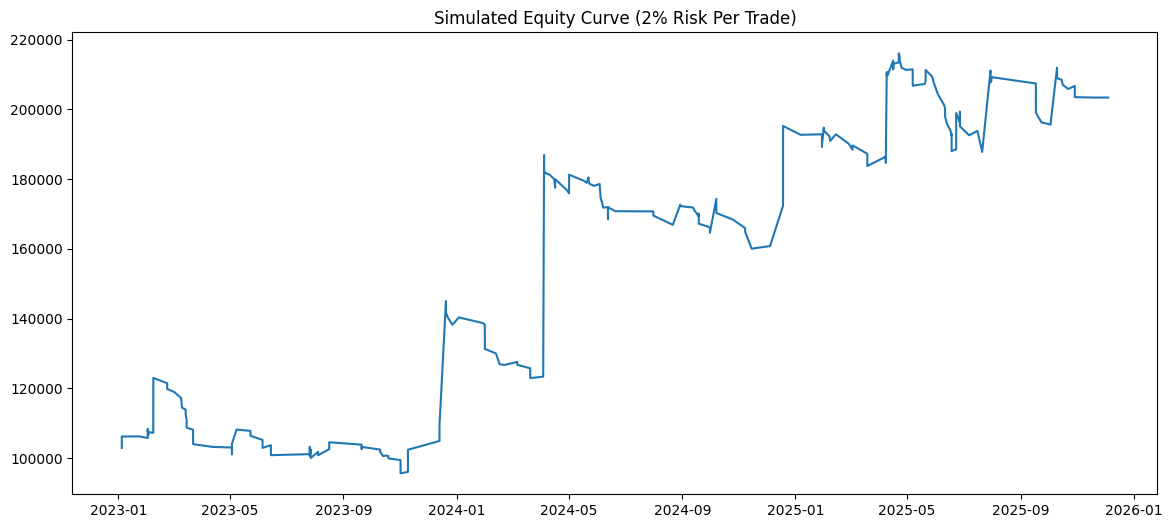

Final Capital: 203405.95504678308
Total Return: 1.034059550467831
Sharpe: 0.08821900227922436
Max Drawdown: -0.2223713604662224


In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ret_df = ret_df.copy()
ret_df['entry_time'] = pd.to_datetime(ret_df['entry_time'])
ret_df = ret_df.sort_values('entry_time').reset_index(drop=True)

# --- PARAMETERS ---
initial_capital = 100000
risk_fraction = 0.02   # 2% of capital per trade

capital = initial_capital
equity_curve = []

for r in ret_df['total_return']:
    position_size = capital * risk_fraction
    pnl = position_size * r
    capital += pnl
    equity_curve.append(capital)

ret_df['equity'] = equity_curve

# --- Portfolio Returns ---
ret_df['portfolio_return'] = ret_df['equity'].pct_change().fillna(0)
ret_df['cum_return'] = ret_df['equity'] / initial_capital

# --- Metrics ---
mean_ret = ret_df['portfolio_return'].mean()
vol = ret_df['portfolio_return'].std()
sharpe = mean_ret / vol if vol != 0 else np.nan

rolling_max = ret_df['equity'].cummax()
drawdown = ret_df['equity'] / rolling_max - 1
max_dd = drawdown.min()

# --- Plot ---
plt.figure(figsize=(14,6))
plt.plot(ret_df['entry_time'], ret_df['equity'])
plt.title("Simulated Equity Curve (2% Risk Per Trade)")
plt.show()

print("Final Capital:", capital)
print("Total Return:", capital/initial_capital - 1)
print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)


In [ ]:
ret_df['portfolio_return']

In [178]:
ret_df['rolling_50'] = ret_df['portfolio_return'].rolling(50).sum()

In [ ]:
# rolling 50 trade return
wins = ret_df[ret_df['total_return'] > 0]['total_return']
losses = ret_df[ret_df['total_return'] <= 0]['total_return']

win_rate = len(wins) / len(ret_df)
avg_win = wins.mean()
avg_loss = losses.mean()

expectancy = win_rate * avg_win + (1 - win_rate) * avg_loss

print(win_rate, avg_win, avg_loss, expectancy)


0.34951456310679613 1.6480176382698961 -0.547033446682534 0.2201688742717135


In [116]:
(df['c'].iloc[-1] - df['c'].iloc[0]) / df['c'].iloc[0]

np.float64(0.8228583613198996)